# 1INF24 Inteligencia Artificial - PUCP
## Tarea Academica Grupal
### Prediccion de lesiones en futbolistas universitarios

**Autores:** Chipana Cuellar, Alonso Daniel | Vizcarra Diaz, Martino Adrian | Changa Gomero, Carlos David

---

| Fase | Contenido |
|---|---|
| **0** | Instalacion e importaciones |
| **1** | Carga del dataset |
| **2** | Analisis Exploratorio (EDA) |
| **3** | Preprocesamiento y definicion de modelos |
| **4** | Validacion cruzada 5-fold |
| **5** | Resultados y visualizaciones |
| **6** | Importancia de features + SHAP |
| **Resumen** | Conclusiones para el informe |


---
## Fase 0 - Instalacion e importaciones

In [1]:
!pip install imbalanced-learn xgboost shap --quiet


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from matplotlib.patches import Patch

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer
from sklearn.metrics import (
    roc_auc_score, f1_score, roc_curve,
    confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = ['#2196F3', '#F44336']
sns.set_palette(PALETTE)


---
## Fase 1 - Carga del dataset


In [5]:
df = pd.read_csv('data.csv')

print('=' * 55)
print('RESUMEN GENERAL DEL DATASET')
print('=' * 55)
print(f'  Jugadores (filas) : {df.shape[0]}')
print(f'  Variables (cols)  : {df.shape[1]}')
print(f'  Valores nulos     : {df.isnull().sum().sum()}')
print()
print('Variables del dataset:')
for col in df.columns:
    print(f'  {col:35s} {df[col].dtype}')


RESUMEN GENERAL DEL DATASET
  Jugadores (filas) : 800
  Variables (cols)  : 19
  Valores nulos     : 0

Variables del dataset:
  Age                                 int64
  Height_cm                           int64
  Weight_kg                           int64
  Position                            object
  Training_Hours_Per_Week             float64
  Matches_Played_Past_Season          int64
  Previous_Injury_Count               int64
  Knee_Strength_Score                 float64
  Hamstring_Flexibility               float64
  Reaction_Time_ms                    float64
  Balance_Test_Score                  float64
  Sprint_Speed_10m_s                  float64
  Agility_Score                       float64
  Sleep_Hours_Per_Night               float64
  Stress_Level_Score                  float64
  Nutrition_Quality_Score             float64
  Warmup_Routine_Adherence            int64
  Injury_Next_Season                  int64
  BMI                                 float64


In [6]:
df.head()


,Age,Height_cm,Weight_kg,Position,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI
0,22,173,64,Midfielder,11.575308,36,1,77.460279,79.115738,284.487853,91.212476,5.874630,77.599705,8.238293,46.616415,81.472206,1,0,21.383942
1,18,170,67,Midfielder,12.275869,37,2,72.634442,82.541688,250.579249,87.294078,5.796269,94.418987,8.983737,49.368037,81.056677,1,0,23.183391
2,22,186,75,Forward,12.254896,12,2,77.064490,75.943631,269.119918,83.440688,5.731209,70.179176,7.229193,43.132808,64.877457,0,1,21.678807
3,20,172,62,Defender,9.006678,11,1,82.810232,73.878324,226.376412,87.591894,6.220212,83.473824,7.681029,51.528529,89.824744,1,0,20.957274
4,18,172,94,Midfielder,12.683668,10,2,76.772859,76.653043,229.021042,83.125161,5.385958,87.037256,6.728091,52.379718,71.569197,0,1,31.773932


In [7]:
df.describe().round(2)


,Age,Height_cm,Weight_kg,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI
count,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.0,800.00
mean,21.14,177.41,73.24,9.95,22.33,1.54,74.93,79.15,249.42,83.83,5.95,78.34,7.42,54.04,74.38,0.60,0.5,23.38
std,1.99,7.15,9.93,2.61,10.31,1.29,6.67,6.78,22.53,6.93,0.33,8.78,0.79,11.42,9.32,0.49,0.5,3.67
min,18.00,154.00,45.00,5.00,5.00,0.00,52.39,58.18,180.00,60.06,4.86,50.00,5.00,21.56,50.00,0.00,0.0,14.35
25%,19.00,173.00,66.00,8.13,13.00,1.00,70.43,74.50,234.09,79.04,5.73,72.68,6.85,45.78,67.81,0.00,0.0,20.79
50%,21.00,177.00,73.00,9.90,22.00,1.00,75.00,79.19,249.13,84.16,5.94,78.34,7.42,54.05,74.36,1.00,0.5,23.13
75%,23.00,182.00,80.00,11.54,32.00,2.00,79.63,83.81,265.11,88.88,6.16,84.09,7.99,61.91,80.50,1.00,1.0,26.02
max,24.00,200.00,105.00,18.87,39.00,8.00,93.90,100.00,306.73,100.00,6.90,100.00,9.86,87.07,100.00,1.00,1.0,36.26


---
## Fase 2 - Analisis Exploratorio de Datos (EDA)

### 2.1 - Balance de clases

Variable objetivo `Injury_Next_Season`:
- **0** -> el jugador NO sufrira una lesion no-contacto de >= 7 dias en los proximos 6 meses
- **1** -> el jugador SI sufrira una lesion no-contacto de >= 7 dias en los proximos 6 meses


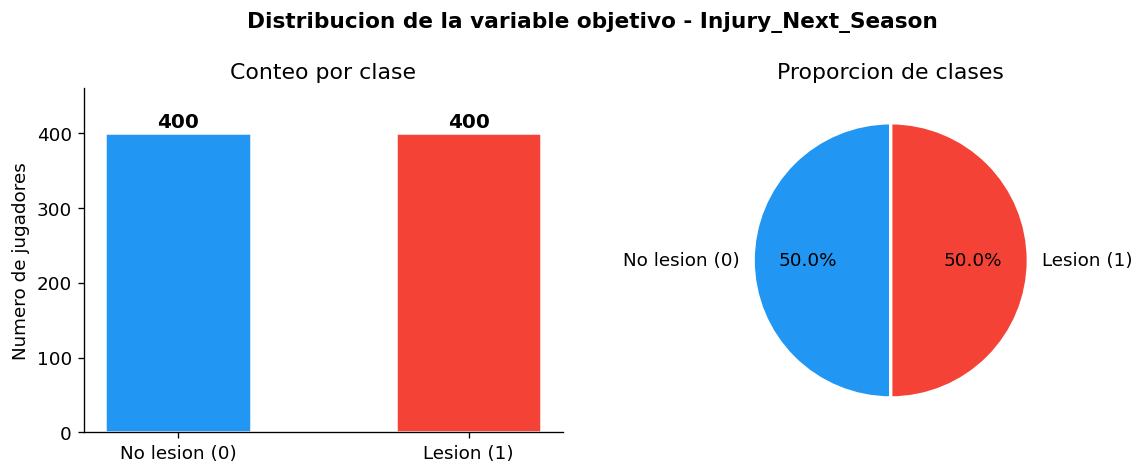

Clase 0 (sin lesion) : 400 jugadores (50.0%)
Clase 1 (con lesion) : 400 jugadores (50.0%)
Ratio desbalance     : 1.00:1

NOTA: dataset balanceado artificialmente (50/50).
En datos reales el desbalance suele ser ~90/10 (Rossi et al., 2018).
SMOTE se mantiene en el pipeline por robustez metodologica.


In [8]:
vc = df['Injury_Next_Season'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Distribucion de la variable objetivo - Injury_Next_Season',
             fontsize=13, fontweight='bold')

labels = ['No lesion (0)', 'Lesion (1)']
axes[0].bar(labels, vc.values, color=PALETTE, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Conteo por clase')
axes[0].set_ylabel('Numero de jugadores')
axes[0].set_ylim(0, vc.max() * 1.15)
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 8, str(v), ha='center', fontweight='bold', fontsize=12)

axes[1].pie(vc.values, labels=labels, colors=PALETTE, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 11})
axes[1].set_title('Proporcion de clases')

plt.tight_layout()
plt.savefig('01_balance_clases.png', bbox_inches='tight')
plt.show()

print(f'Clase 0 (sin lesion) : {vc[0]} jugadores ({vc[0]/len(df)*100:.1f}%)')
print(f'Clase 1 (con lesion) : {vc[1]} jugadores ({vc[1]/len(df)*100:.1f}%)')
print(f'Ratio desbalance     : {vc[0]/vc[1]:.2f}:1')
print()
print('NOTA: dataset balanceado artificialmente (50/50).')
print('En datos reales el desbalance suele ser ~90/10 (Rossi et al., 2018).')
print('SMOTE se mantiene en el pipeline por robustez metodologica.')


### 2.2 - Distribucion por posicion y tasa de lesion


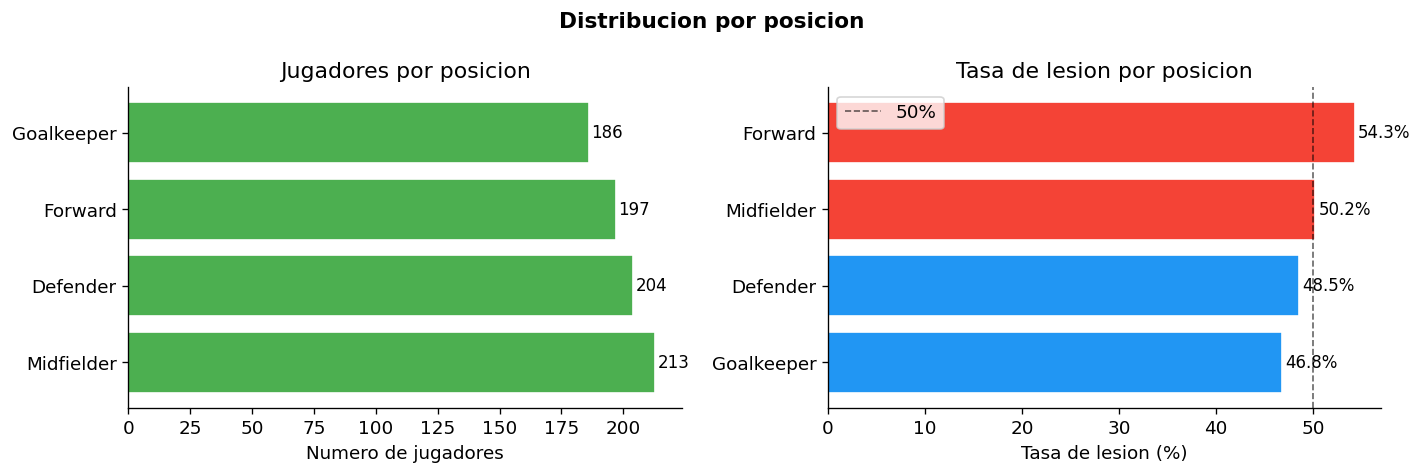

Tasa de lesion por posicion:
            Total  Lesionados  Tasa_pct
Position                               
Forward       197         107      54.3
Midfielder    213         107      50.2
Defender      204          99      48.5
Goalkeeper    186          87      46.8


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribucion por posicion', fontsize=13, fontweight='bold')

pos_counts = df['Position'].value_counts()
axes[0].barh(pos_counts.index, pos_counts.values, color='#4CAF50', edgecolor='white')
axes[0].set_xlabel('Numero de jugadores')
axes[0].set_title('Jugadores por posicion')
for i, (idx, val) in enumerate(zip(pos_counts.index, pos_counts.values)):
    axes[0].text(val + 1, i, str(val), va='center', fontsize=10)

pos_injury = df.groupby('Position')['Injury_Next_Season'].mean().sort_values()
colors_bar = ['#F44336' if v > 0.5 else '#2196F3' for v in pos_injury.values]
axes[1].barh(pos_injury.index, pos_injury.values * 100, color=colors_bar, edgecolor='white')
axes[1].axvline(50, color='black', linestyle='--', linewidth=1, alpha=0.6, label='50%')
axes[1].set_xlabel('Tasa de lesion (%)')
axes[1].set_title('Tasa de lesion por posicion')
axes[1].legend()
for i, (idx, val) in enumerate(zip(pos_injury.index, pos_injury.values)):
    axes[1].text(val * 100 + 0.3, i, f'{val*100:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('02_posicion_lesion.png', bbox_inches='tight')
plt.show()

pos_table = df.groupby('Position')['Injury_Next_Season'].agg(
    Total='count', Lesionados='sum',
    Tasa_pct=lambda x: round(x.mean() * 100, 1)
)
print('Tasa de lesion por posicion:')
print(pos_table.sort_values('Tasa_pct', ascending=False).to_string())


### 2.3 - Correlacion de variables con la variable objetivo


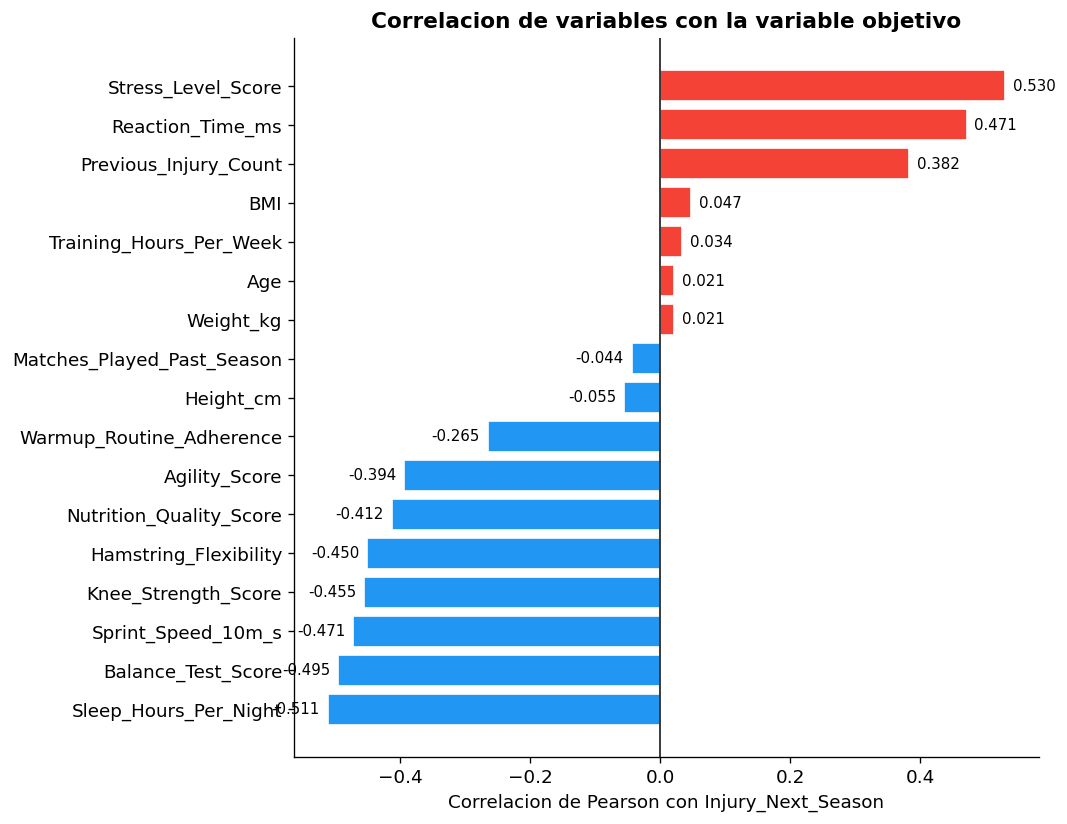

TOP 5 Factores de RIESGO (correlacion positiva):
Stress_Level_Score         0.5300
Reaction_Time_ms           0.4709
Previous_Injury_Count      0.3822
BMI                        0.0474
Training_Hours_Per_Week    0.0338

TOP 5 Factores PROTECTORES (correlacion negativa):
Sleep_Hours_Per_Night   -0.5109
Balance_Test_Score      -0.4948
Sprint_Speed_10m_s      -0.4715
Knee_Strength_Score     -0.4546
Hamstring_Flexibility   -0.4503


In [10]:
numeric_df  = df.drop(columns=['Position'])
corr_target = (numeric_df.corr()['Injury_Next_Season']
               .drop('Injury_Next_Season')
               .sort_values())

colors_corr = ['#F44336' if c > 0 else '#2196F3' for c in corr_target.values]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(corr_target.index, corr_target.values,
               color=colors_corr, edgecolor='white', linewidth=1)
ax.axvline(0, color='black', linewidth=0.9)
ax.set_xlabel('Correlacion de Pearson con Injury_Next_Season')
ax.set_title('Correlacion de variables con la variable objetivo',
             fontweight='bold', fontsize=13)
for bar, val in zip(bars, corr_target.values):
    x  = val + 0.012 if val >= 0 else val - 0.012
    ha = 'left' if val >= 0 else 'right'
    ax.text(x, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha=ha, fontsize=9)
plt.tight_layout()
plt.savefig('03_correlacion_objetivo.png', bbox_inches='tight')
plt.show()

print('TOP 5 Factores de RIESGO (correlacion positiva):')
print(corr_target.tail(5)[::-1].round(4).to_string())
print()
print('TOP 5 Factores PROTECTORES (correlacion negativa):')
print(corr_target.head(5).round(4).to_string())


### 2.4 - Distribuciones de las 8 variables mas predictivas por clase


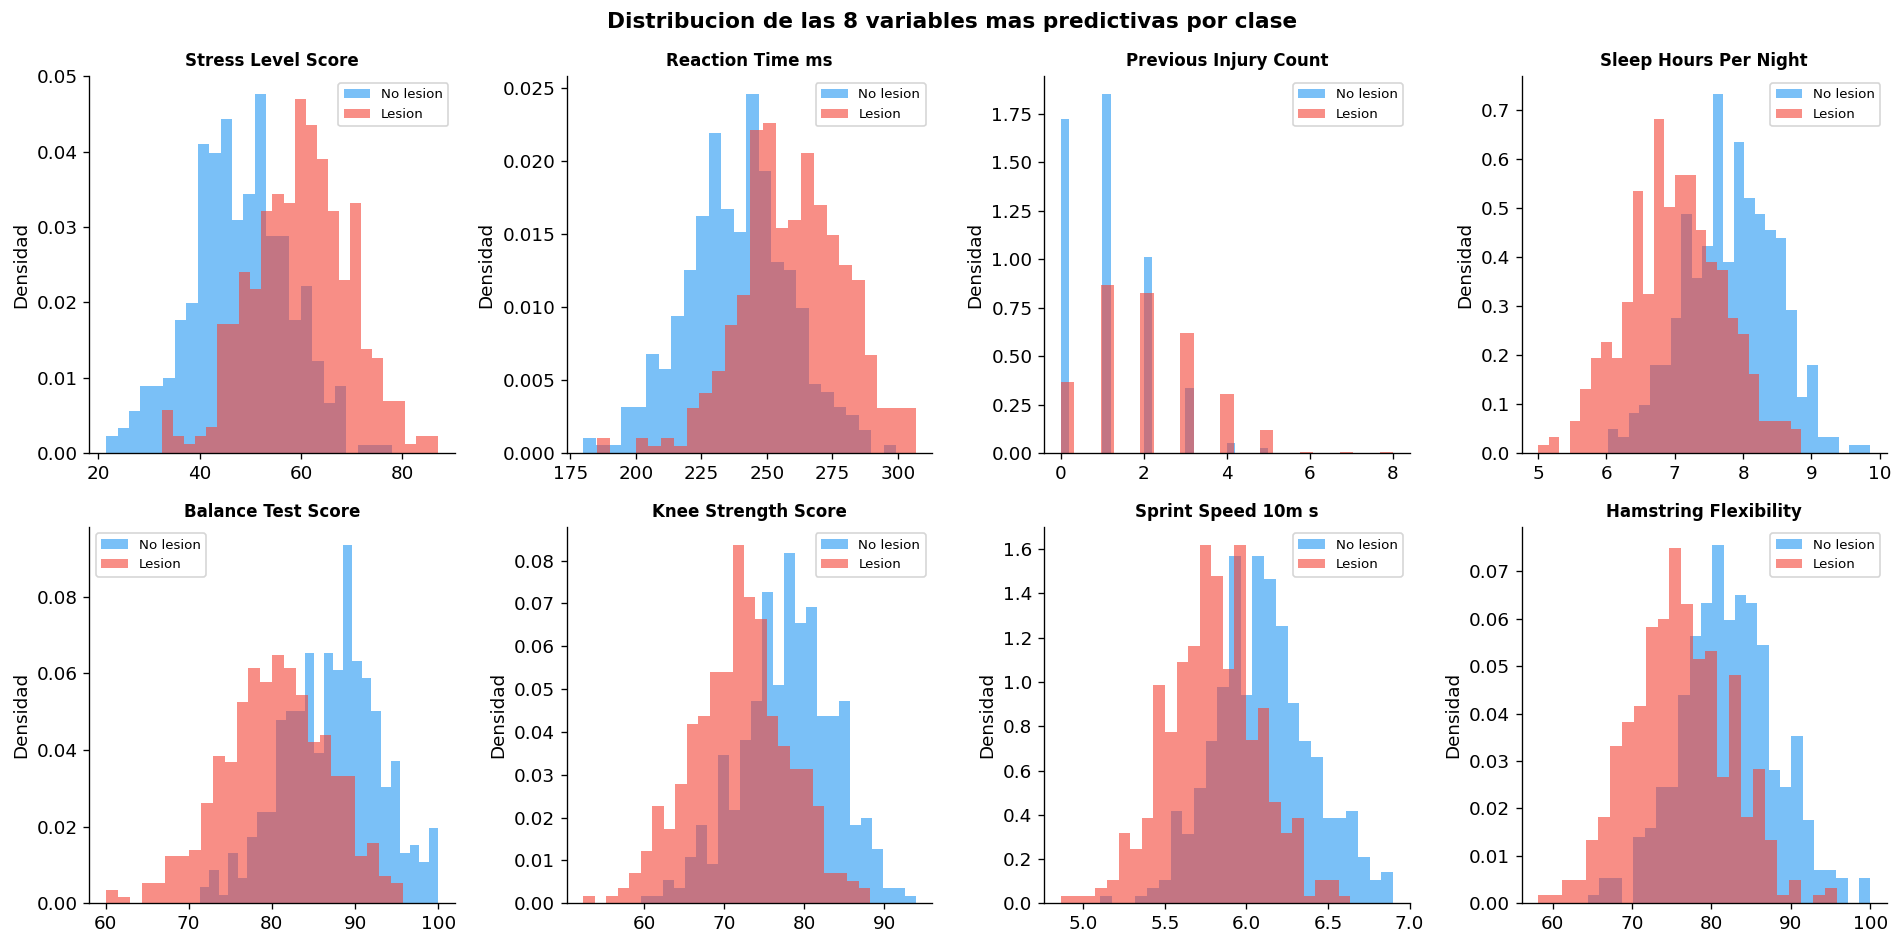

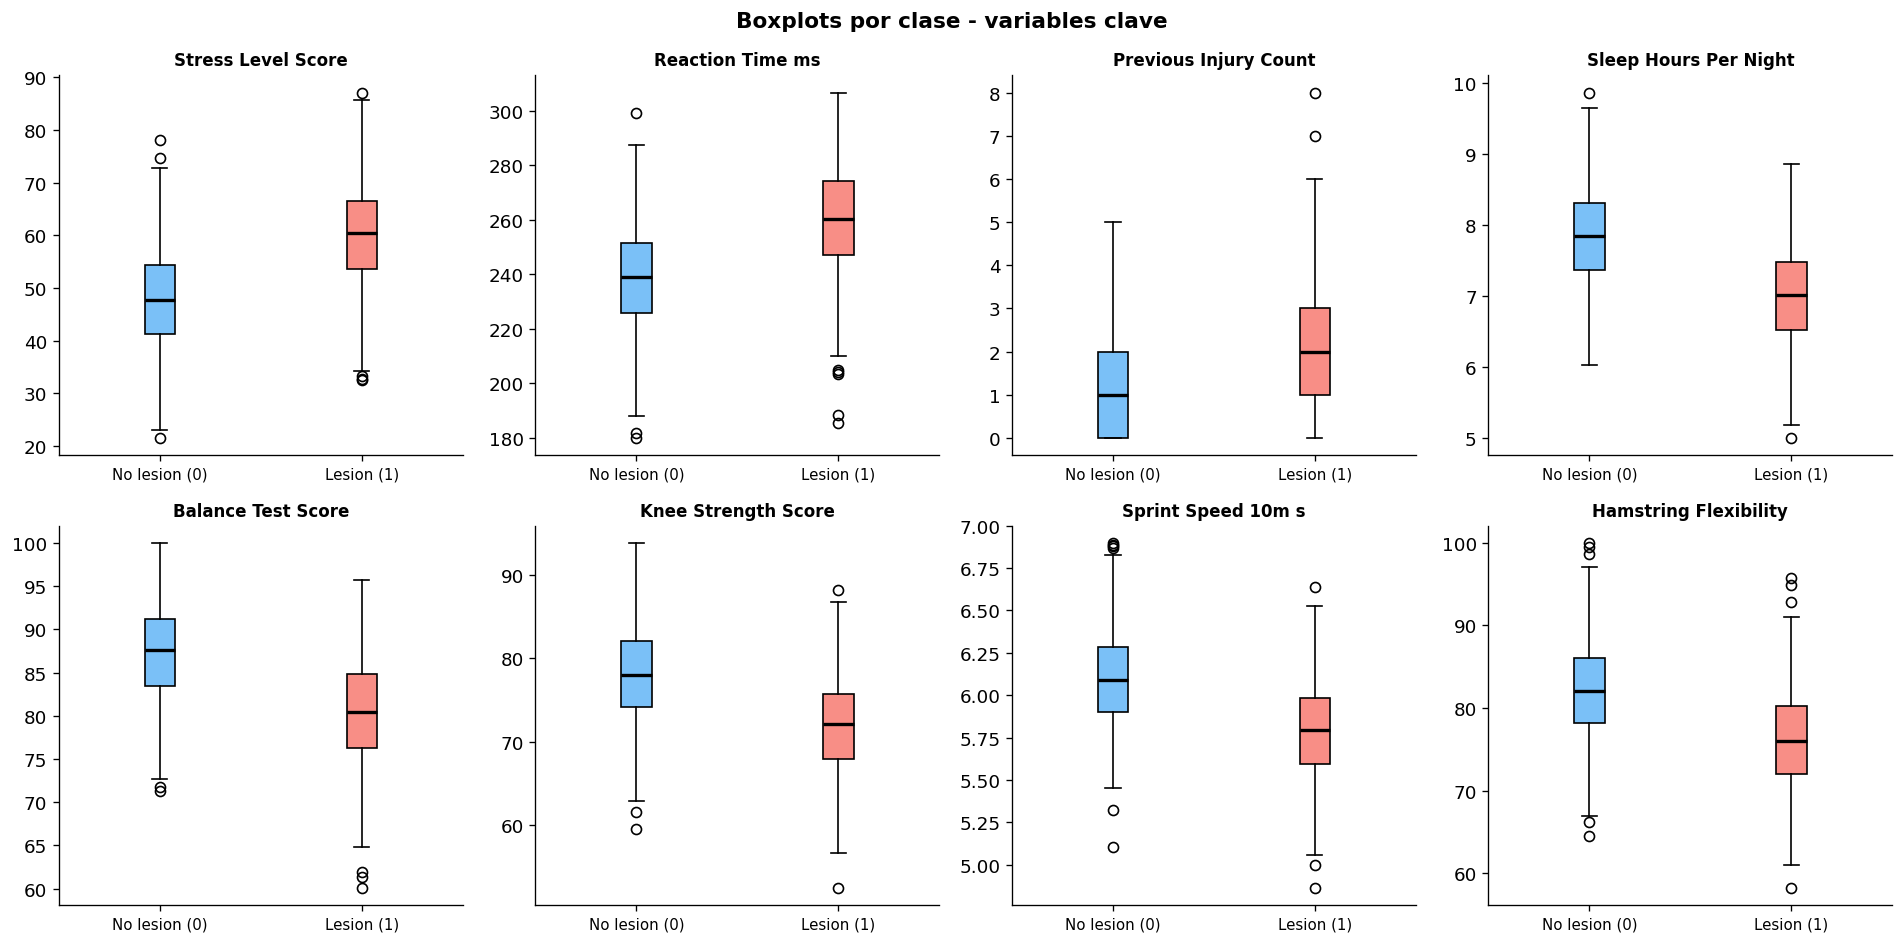

In [11]:
TOP_VARS = [
    'Stress_Level_Score', 'Reaction_Time_ms', 'Previous_Injury_Count',
    'Sleep_Hours_Per_Night', 'Balance_Test_Score', 'Knee_Strength_Score',
    'Sprint_Speed_10m_s', 'Hamstring_Flexibility'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
fig.suptitle('Distribucion de las 8 variables mas predictivas por clase',
             fontsize=13, fontweight='bold')
for i, col in enumerate(TOP_VARS):
    for label, color, name in zip([0, 1], PALETTE, ['No lesion', 'Lesion']):
        axes[i].hist(df[df['Injury_Next_Season'] == label][col],
                     bins=25, alpha=0.60, color=color, label=name, density=True)
    axes[i].set_title(col.replace('_', ' '), fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Densidad')
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.savefig('04_distribuciones_por_clase.png', bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
fig.suptitle('Boxplots por clase - variables clave', fontsize=13, fontweight='bold')
for i, col in enumerate(TOP_VARS):
    data_plot = [df[df['Injury_Next_Season'] == k][col].values for k in [0, 1]]
    bp = axes[i].boxplot(data_plot, patch_artist=True,
                          medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(PALETTE[0] + '99')
    bp['boxes'][1].set_facecolor(PALETTE[1] + '99')
    axes[i].set_title(col.replace('_', ' '), fontweight='bold', fontsize=10)
    axes[i].set_xticklabels(['No lesion (0)', 'Lesion (1)'], fontsize=9)
plt.tight_layout()
plt.savefig('05_boxplots_clase.png', bbox_inches='tight')
plt.show()


### 2.5 - Matriz de correlacion completa y multicolinealidad


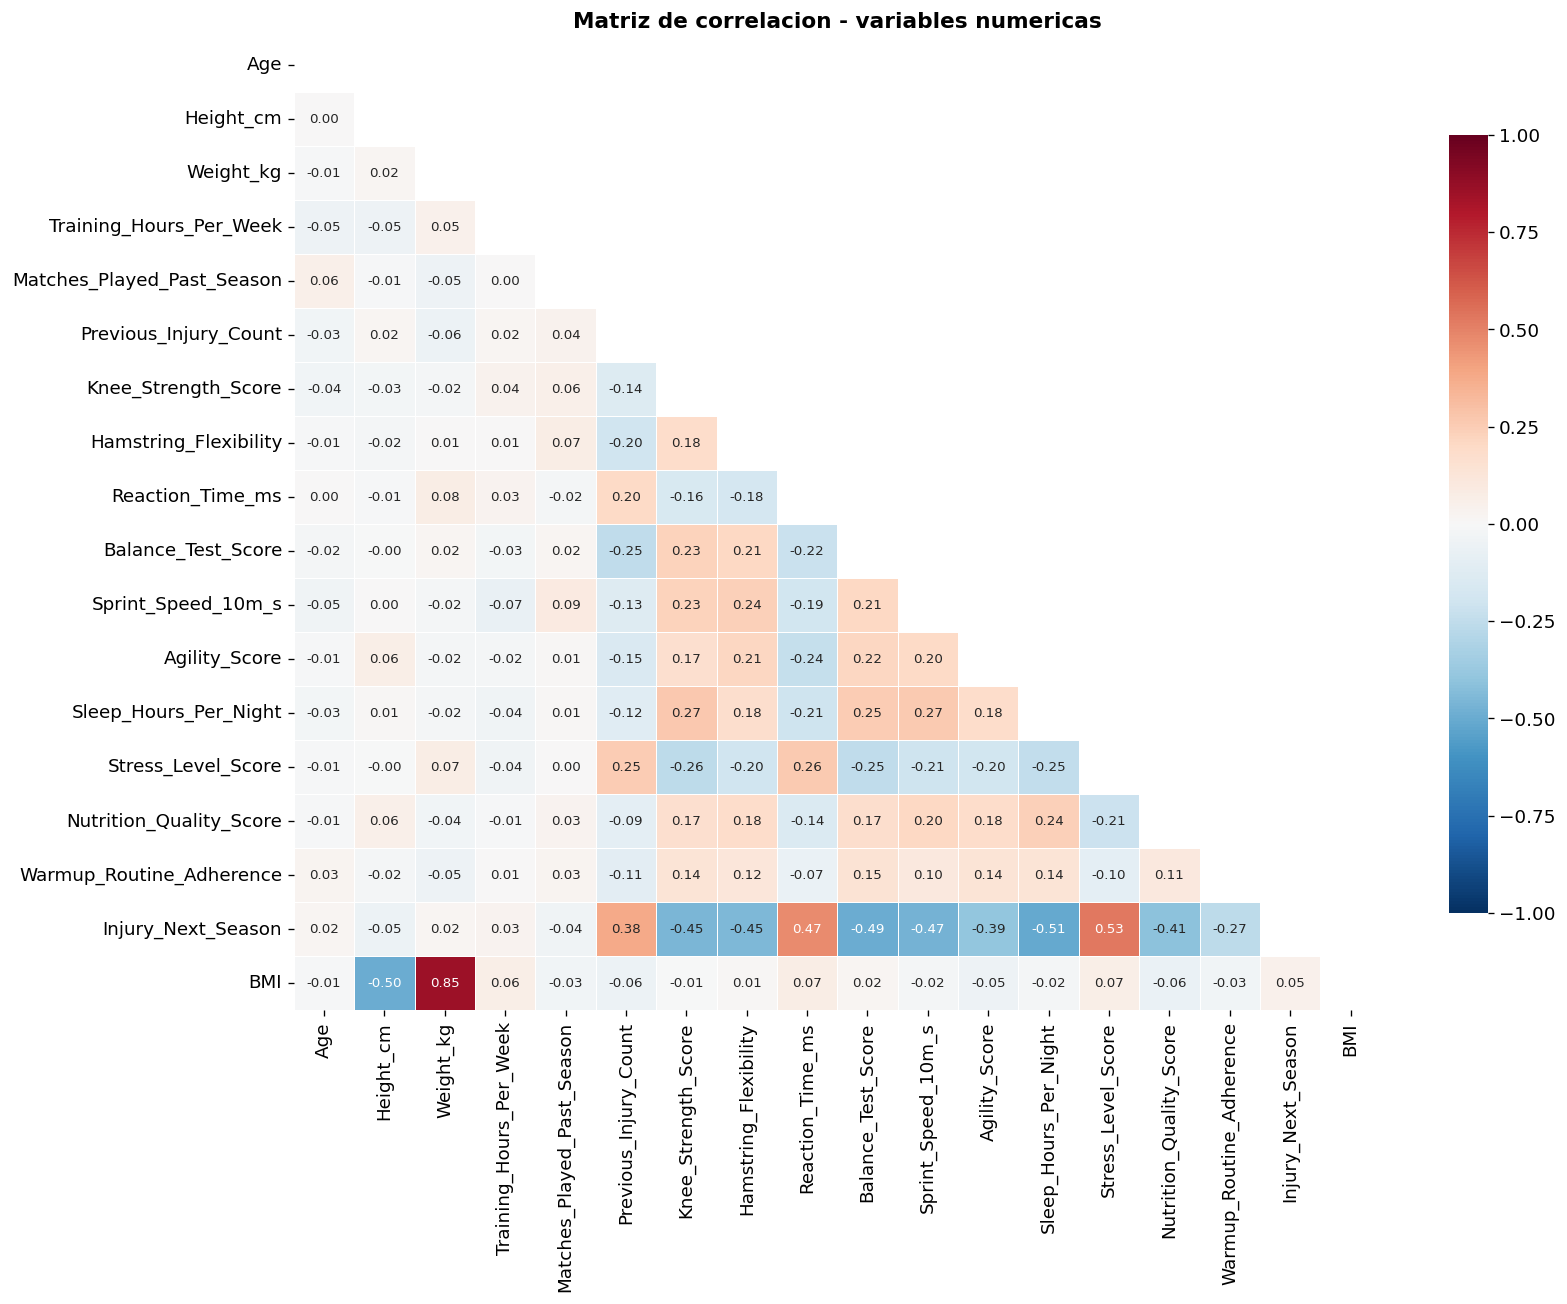

Pares con |r| > 0.70 (posible multicolinealidad):
  Weight_kg                      <-> BMI                            : 0.854


In [12]:
fig, ax = plt.subplots(figsize=(14, 11))
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlacion - variables numericas', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('06_matriz_correlacion.png', bbox_inches='tight')
plt.show()

features_corr = numeric_df.drop(columns=['Injury_Next_Season']).corr()
print('Pares con |r| > 0.70 (posible multicolinealidad):')
found = False
for i in range(len(features_corr.columns)):
    for j in range(i + 1, len(features_corr.columns)):
        val = features_corr.iloc[i, j]
        if abs(val) > 0.70:
            print(f'  {features_corr.columns[i]:30s} <-> {features_corr.columns[j]:30s} : {val:.3f}')
            found = True
if not found:
    print('  Sin multicolinealidad severa (ningun par supera |r| = 0.70)')


### 2.6 - Test Mann-Whitney U y deteccion de outliers


In [13]:
key_cols = [
    'Stress_Level_Score', 'Reaction_Time_ms', 'Previous_Injury_Count',
    'Sleep_Hours_Per_Night', 'Balance_Test_Score', 'Knee_Strength_Score',
    'Sprint_Speed_10m_s', 'Hamstring_Flexibility', 'Agility_Score',
    'Nutrition_Quality_Score', 'Warmup_Routine_Adherence',
    'Training_Hours_Per_Week', 'BMI', 'Age'
]
g0 = df[df['Injury_Next_Season'] == 0]
g1 = df[df['Injury_Next_Season'] == 1]

mw_rows = []
for col in key_cols:
    _, p = stats.mannwhitneyu(g0[col], g1[col], alternative='two-sided')
    mw_rows.append({
        'Variable':           col,
        'Media (No lesion)':  round(g0[col].mean(), 3),
        'Media (Lesion)':     round(g1[col].mean(), 3),
        'p-valor':            round(p, 6),
        'Sig. (alfa=0.05)':  'Si' if p < 0.05 else 'No'
    })

mw_df = pd.DataFrame(mw_rows).sort_values('p-valor')
print('Test Mann-Whitney U - diferencias entre clases:')
display(mw_df.reset_index(drop=True))

print()
print('Outliers por variable (|Z-score| > 3):')
num_cols_out = [c for c in numeric_df.columns
                if c not in ['Injury_Next_Season', 'Warmup_Routine_Adherence']]
for col in num_cols_out:
    z     = np.abs((df[col] - df[col].mean()) / df[col].std())
    n_out = (z > 3).sum()
    if n_out > 0:
        print(f'  {col:35s} {n_out:>3} outliers ({n_out/len(df)*100:.1f}%)')
print('  -> Outliers escasos y biologicamente plausibles; se conservan.')


Test Mann-Whitney U - diferencias entre clases:


,Variable,Media (No lesion),Media (Lesion),p-valor,Sig. (alfa=0.05)
0,Stress_Level_Score,47.990,60.088,0.000000,Si
1,Reaction_Time_ms,238.820,260.027,0.000000,Si
2,Previous_Injury_Count,1.042,2.030,0.000000,Si
3,Sleep_Hours_Per_Night,7.822,7.012,0.000000,Si
4,Balance_Test_Score,87.260,80.405,0.000000,Si
5,Knee_Strength_Score,77.964,71.902,0.000000,Si
6,Sprint_Speed_10m_s,6.104,5.794,0.000000,Si
7,Hamstring_Flexibility,82.206,76.102,0.000000,Si
8,Agility_Score,81.794,74.889,0.000000,Si
9,Nutrition_Quality_Score,78.226,70.538,0.000000,Si



Outliers por variable (|Z-score| > 3):
  Height_cm                             3 outliers (0.4%)
  Weight_kg                             1 outliers (0.1%)
  Training_Hours_Per_Week               2 outliers (0.2%)
  Previous_Injury_Count                 3 outliers (0.4%)
  Knee_Strength_Score                   1 outliers (0.1%)
  Hamstring_Flexibility                 2 outliers (0.2%)
  Reaction_Time_ms                      2 outliers (0.2%)
  Balance_Test_Score                    3 outliers (0.4%)
  Sprint_Speed_10m_s                    1 outliers (0.1%)
  Agility_Score                         1 outliers (0.1%)
  Sleep_Hours_Per_Night                 2 outliers (0.2%)
  BMI                                   3 outliers (0.4%)
  -> Outliers escasos y biologicamente plausibles; se conservan.


---
## Fase 3 - Preprocesamiento y definicion de modelos

### 3.1 - Separacion features / target y One-Hot Encoding

`Position` -> One-Hot Encoding (4 columnas binarias, `drop_first=False`).  
`Warmup_Routine_Adherence` -> ya es binaria (0/1), sin transformacion.  
`BMI` -> feature derivada ya calculada, se incluye directamente.

### 3.2 - Pipeline de preprocesamiento

| Paso | Componente | Justificacion |
|---|---|---|
| 1 | `KNNImputer(k=5)` | Imputa por similitud (no hay nulos; se mantiene por robustez) |
| 2 | `StandardScaler` | Z-score obligatorio para LR; se aplica uniformemente |
| 3 | `SMOTE` | Sobremuestra la clase minoritaria **solo en el training fold** |


In [14]:
y = df['Injury_Next_Season'].values
X = df.drop(columns=['Injury_Next_Season'])
X = pd.get_dummies(X, columns=['Position'], drop_first=False)

FEATURE_NAMES = X.columns.tolist()
N_FEATURES    = X.shape[1]

print(f'Features tras OHE : {N_FEATURES}')
print('Columnas finales:')
for i, col in enumerate(FEATURE_NAMES, 1):
    print(f'  {i:2d}. {col}')


Features tras OHE : 21
Columnas finales:
   1. Age
   2. Height_cm
   3. Weight_kg
   4. Training_Hours_Per_Week
   5. Matches_Played_Past_Season
   6. Previous_Injury_Count
   7. Knee_Strength_Score
   8. Hamstring_Flexibility
   9. Reaction_Time_ms
  10. Balance_Test_Score
  11. Sprint_Speed_10m_s
  12. Agility_Score
  13. Sleep_Hours_Per_Night
  14. Stress_Level_Score
  15. Nutrition_Quality_Score
  16. Warmup_Routine_Adherence
  17. BMI
  18. Position_Defender
  19. Position_Forward
  20. Position_Goalkeeper
  21. Position_Midfielder


In [15]:
n_neg = (y == 0).sum()
n_pos = (y == 1).sum()
SPW   = n_neg / n_pos
print(f'n_neg={n_neg}  n_pos={n_pos}  scale_pos_weight={SPW:.2f}')

PREP = [
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler',  StandardScaler()),
    ('smote',   SMOTE(random_state=SEED)),
]

# Modelo 1: Regresion Logistica (baseline)
pipe_lr = ImbPipeline(PREP + [
    ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=SEED))
])

# Modelo 2: Random Forest adaptado
pipe_rf = ImbPipeline(PREP + [
    ('clf', RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=SEED))
])

# Modelo 3: XGBoost adaptado
pipe_xgb = ImbPipeline(PREP + [
    ('clf', xgb.XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=SPW, eval_metric='logloss',
        random_state=SEED, verbosity=0))
])

MODELS = {
    'Regresion Logistica (baseline)': pipe_lr,
    'Random Forest':                   pipe_rf,
    'XGBoost':                         pipe_xgb,
}
print('Pipelines definidos:')
for name in MODELS:
    print(f'  {name}')


n_neg=400  n_pos=400  scale_pos_weight=1.00
Pipelines definidos:
  Regresion Logistica (baseline)
  Random Forest
  XGBoost


---
## Fase 4 - Validacion cruzada estratificada 5-fold

En cada iteracion k:
1. El modelo se entrena sobre los 4 folds restantes (SMOTE solo actua aqui).
2. El **umbral tau** se determina con el criterio de **Youden** (J = Sensibilidad + Especificidad - 1).
3. Se evalua AUC-ROC y F1-Score sobre el fold k (datos nunca vistos).

Las metricas finales se reportan como **promedio +/- desviacion estandar** sobre 5 folds.


In [16]:
skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results   = {}
roc_data  = {}
conf_mats = {}

for model_name, pipeline in MODELS.items():
    print(f'\n' + '='*60)
    print(f'Entrenando: {model_name}')
    print('='*60)

    aucs, f1s   = [], []
    tprs_interp = []
    mean_fpr    = np.linspace(0, 1, 200)
    cm_total    = np.zeros((2, 2), dtype=int)

    for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y[tr_idx],      y[te_idx]

        pipeline.fit(X_tr, y_tr)
        proba = pipeline.predict_proba(X_te)[:, 1]

        fpr, tpr, thresholds = roc_curve(y_te, proba)
        tau  = thresholds[np.argmax(tpr - fpr)]
        pred = (proba >= tau).astype(int)

        auc = roc_auc_score(y_te, proba)
        f1  = f1_score(y_te, pred)
        aucs.append(auc)
        f1s.append(f1)
        tprs_interp.append(np.interp(mean_fpr, fpr, tpr))
        cm_total += confusion_matrix(y_te, pred)

        print(f'  Fold {fold}: AUC={auc:.4f}  F1={f1:.4f}  tau={tau:.4f}')

    results[model_name] = {
        'AUC_mean': np.mean(aucs), 'AUC_std': np.std(aucs),
        'F1_mean':  np.mean(f1s),  'F1_std':  np.std(f1s),
    }
    roc_data[model_name]  = (mean_fpr,
                              np.mean(tprs_interp, axis=0),
                              np.std(tprs_interp, axis=0))
    conf_mats[model_name] = cm_total
    print(f'  -> AUC: {np.mean(aucs):.4f} +/- {np.std(aucs):.4f}  '
          f'F1: {np.mean(f1s):.4f} +/- {np.std(f1s):.4f}')

print('\nValidacion cruzada completa')



Entrenando: Regresion Logistica (baseline)
  Fold 1: AUC=0.9952  F1=0.9620  tau=0.5993
  Fold 2: AUC=0.9881  F1=0.9565  tau=0.7330
  Fold 3: AUC=0.9877  F1=0.9548  tau=0.6546
  Fold 4: AUC=0.9905  F1=0.9548  tau=0.8099
  Fold 5: AUC=0.9898  F1=0.9625  tau=0.3996
  -> AUC: 0.9902 +/- 0.0027  F1: 0.9581 +/- 0.0034

Entrenando: Random Forest
  Fold 1: AUC=0.9913  F1=0.9560  tau=0.5300
  Fold 2: AUC=0.9837  F1=0.9487  tau=0.6100
  Fold 3: AUC=0.9882  F1=0.9494  tau=0.5300
  Fold 4: AUC=0.9796  F1=0.9359  tau=0.6100
  Fold 5: AUC=0.9863  F1=0.9434  tau=0.5000
  -> AUC: 0.9858 +/- 0.0040  F1: 0.9467 +/- 0.0067

Entrenando: XGBoost
  Fold 1: AUC=0.9917  F1=0.9625  tau=0.4648
  Fold 2: AUC=0.9855  F1=0.9518  tau=0.2122
  Fold 3: AUC=0.9877  F1=0.9548  tau=0.6500
  Fold 4: AUC=0.9777  F1=0.9211  tau=0.8335
  Fold 5: AUC=0.9902  F1=0.9506  tau=0.3826
  -> AUC: 0.9865 +/- 0.0049  F1: 0.9482 +/- 0.0142

Validacion cruzada completa


---
## Fase 5 - Resultados y visualizaciones

### 5.1 - Tabla comparativa


In [17]:
rows = []
for name, m in results.items():
    rows.append({
        'Modelo':          name,
        'AUC-ROC (mean)':  round(m['AUC_mean'], 4),
        'AUC-ROC (std)':   round(m['AUC_std'],  4),
        'F1-Score (mean)': round(m['F1_mean'],  4),
        'F1-Score (std)':  round(m['F1_std'],   4),
        'AUC >= 0.75':    'SI' if m['AUC_mean'] >= 0.75 else 'NO',
        'F1 >= 0.65':     'SI' if m['F1_mean']  >= 0.65 else 'NO',
    })

res_df = pd.DataFrame(rows).set_index('Modelo')
print('RESULTADOS - 5-Fold Cross-Validation Estratificada')
display(res_df)

best = max(results, key=lambda k: results[k]['AUC_mean'])
print(f'\nMejor modelo por AUC-ROC : {best}')
print(f'  AUC-ROC  = {results[best]["AUC_mean"]:.4f} +/- {results[best]["AUC_std"]:.4f}')
print(f'  F1-Score = {results[best]["F1_mean"]:.4f} +/- {results[best]["F1_std"]:.4f}')


RESULTADOS - 5-Fold Cross-Validation Estratificada


,AUC-ROC (mean),AUC-ROC (std),F1-Score (mean),F1-Score (std),AUC >= 0.75,F1 >= 0.65
Modelo,,,,,,
Regresion Logistica (baseline),0.9902,0.0027,0.9581,0.0034,SI,SI
Random Forest,0.9858,0.0040,0.9467,0.0067,SI,SI
XGBoost,0.9865,0.0049,0.9482,0.0142,SI,SI



Mejor modelo por AUC-ROC : Regresion Logistica (baseline)
  AUC-ROC  = 0.9902 +/- 0.0027
  F1-Score = 0.9581 +/- 0.0034


### 5.2 - Curvas ROC comparativas


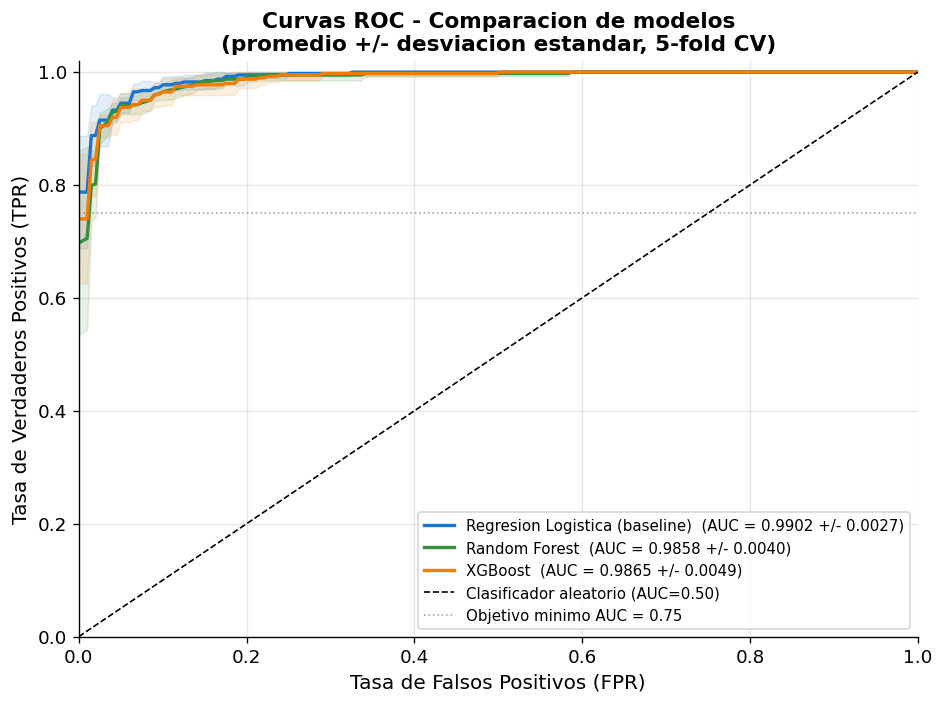

In [18]:
COLORS_ROC = ['#1976D2', '#388E3C', '#F57C00']

fig, ax = plt.subplots(figsize=(8, 6))
for (name, (mean_fpr, mean_tpr, std_tpr)), color in zip(roc_data.items(), COLORS_ROC):
    auc_v = results[name]['AUC_mean']
    auc_s = results[name]['AUC_std']
    ax.plot(mean_fpr, mean_tpr, color=color, linewidth=2,
            label=f'{name}  (AUC = {auc_v:.4f} +/- {auc_s:.4f})')
    ax.fill_between(mean_fpr,
                    np.maximum(mean_tpr - std_tpr, 0),
                    np.minimum(mean_tpr + std_tpr, 1),
                    color=color, alpha=0.12)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio (AUC=0.50)')
ax.axhline(0.75, color='gray', linestyle=':', linewidth=1, alpha=0.7,
           label='Objetivo minimo AUC = 0.75')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC - Comparacion de modelos\n'
             '(promedio +/- desviacion estandar, 5-fold CV)',
             fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('07_curvas_roc.png', bbox_inches='tight')
plt.show()


### 5.3 - Matrices de confusion acumuladas (5-fold)


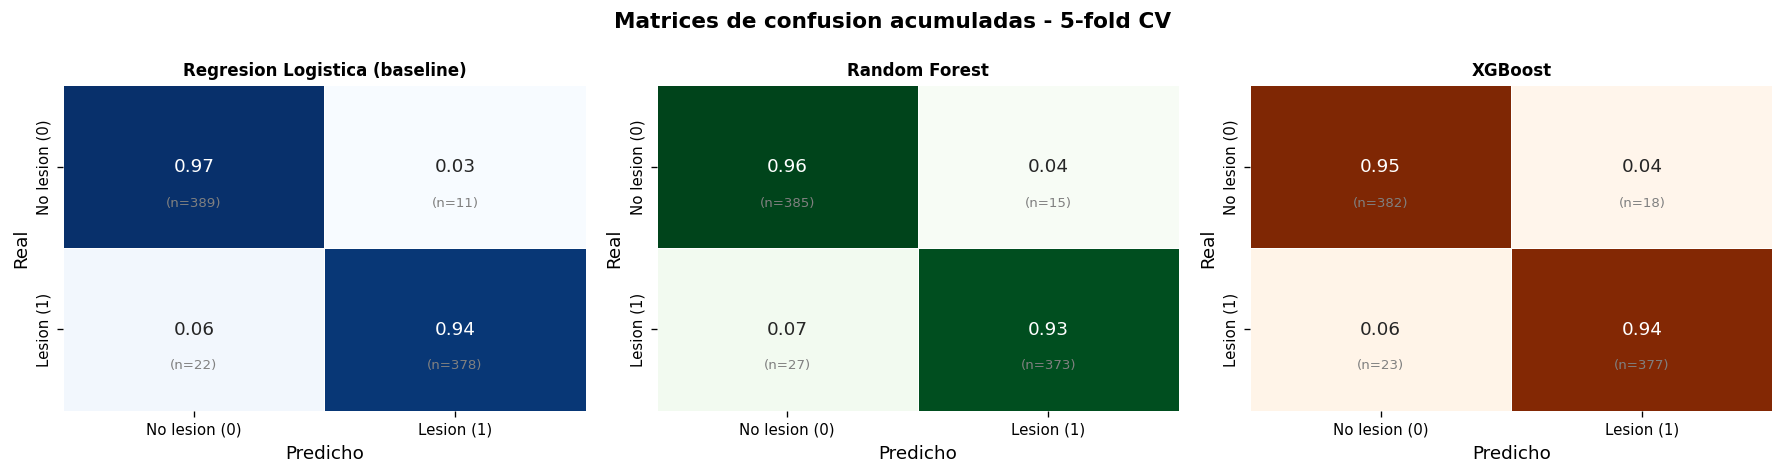

Metricas por clase (umbral de Youden):
  Regresion Logistica (baseline)       Recall-lesion=0.945  Recall-no-lesion=0.973  Precision-lesion=0.972
  Random Forest                        Recall-lesion=0.932  Recall-no-lesion=0.963  Precision-lesion=0.961
  XGBoost                              Recall-lesion=0.943  Recall-no-lesion=0.955  Precision-lesion=0.954


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Matrices de confusion acumuladas - 5-fold CV',
             fontsize=13, fontweight='bold')

class_labels = ['No lesion (0)', 'Lesion (1)']
CMAPS        = ['Blues', 'Greens', 'Oranges']

for ax, (name, cm), cmap in zip(axes, conf_mats.items(), CMAPS):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=class_labels, yticklabels=class_labels,
                ax=ax, linewidths=0.5, cbar=False, annot_kws={'size': 11})
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.72, f'(n={cm[i,j]})',
                    ha='center', va='center', fontsize=8, color='gray')
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
    ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('08_matrices_confusion.png', bbox_inches='tight')
plt.show()

print('Metricas por clase (umbral de Youden):')
for name, cm in conf_mats.items():
    tn, fp, fn, tp = cm.ravel()
    print(f'  {name:35s}  '
          f'Recall-lesion={tp/(tp+fn):.3f}  '
          f'Recall-no-lesion={tn/(tn+fp):.3f}  '
          f'Precision-lesion={tp/(tp+fp):.3f}')


---
## Fase 6 - Importancia de features e interpretabilidad SHAP

### 6.1 - Importancia por indice de Gini - Random Forest


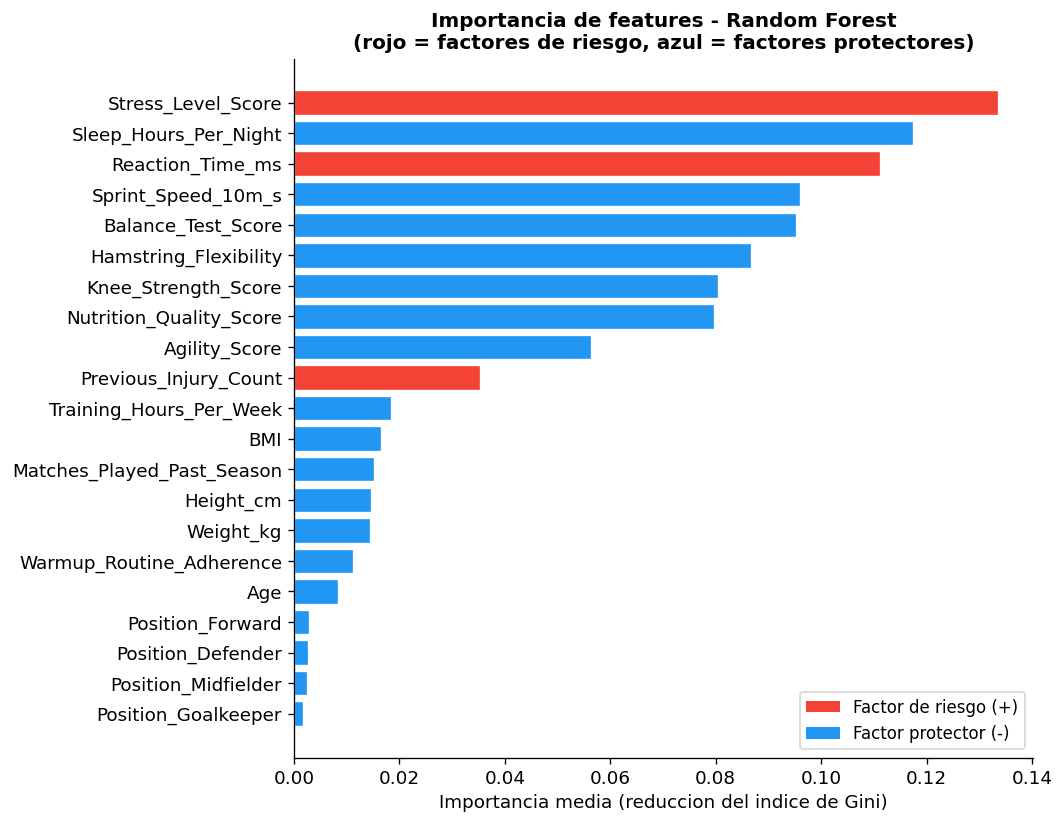

Top 10 features (Random Forest - importancia Gini):
                Feature  Importancia (Gini)
     Stress_Level_Score            0.133515
  Sleep_Hours_Per_Night            0.117514
       Reaction_Time_ms            0.111178
     Sprint_Speed_10m_s            0.096045
     Balance_Test_Score            0.095176
  Hamstring_Flexibility            0.086633
    Knee_Strength_Score            0.080351
Nutrition_Quality_Score            0.079725
          Agility_Score            0.056413
  Previous_Injury_Count            0.035222


In [20]:
pipe_rf_full = ImbPipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler',  StandardScaler()),
    ('smote',   SMOTE(random_state=SEED)),
    ('clf',     RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=SEED))
])
pipe_rf_full.fit(X, y)

rf_imp = pipe_rf_full.named_steps['clf'].feature_importances_
imp_df = (pd.DataFrame({'Feature': FEATURE_NAMES, 'Importancia (Gini)': rf_imp})
           .sort_values('Importancia (Gini)', ascending=True))

RISK_VARS  = ['Stress_Level_Score', 'Reaction_Time_ms', 'Previous_Injury_Count']
colors_imp = ['#F44336' if f in RISK_VARS else '#2196F3' for f in imp_df['Feature']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(imp_df['Feature'], imp_df['Importancia (Gini)'],
        color=colors_imp, edgecolor='white', linewidth=0.8)
ax.set_xlabel('Importancia media (reduccion del indice de Gini)')
ax.set_title('Importancia de features - Random Forest\n'
             '(rojo = factores de riesgo, azul = factores protectores)',
             fontweight='bold', fontsize=12)
ax.legend(handles=[Patch(facecolor='#F44336', label='Factor de riesgo (+)'),
                   Patch(facecolor='#2196F3', label='Factor protector (-)')],
          loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('09_importancia_rf.png', bbox_inches='tight')
plt.show()

print('Top 10 features (Random Forest - importancia Gini):')
print(imp_df.sort_values('Importancia (Gini)', ascending=False).head(10).to_string(index=False))


### 6.2 - SHAP values - XGBoost

Los **SHAP values** cuantifican la contribucion de cada feature a la prediccion individual
de cada jugador (Ma, Liu y Pei, 2025). Permite al cuerpo medico interpretar el riesgo
de forma personalizada.


In [21]:
pipe_xgb_full = ImbPipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler',  StandardScaler()),
    ('smote',   SMOTE(random_state=SEED)),
    ('clf',     xgb.XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=SPW,
        eval_metric='logloss', random_state=SEED, verbosity=0))
])
pipe_xgb_full.fit(X, y)

prep_only = SkPipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler',  StandardScaler()),
])
prep_only.fit(X, y)
X_prep = pd.DataFrame(prep_only.transform(X), columns=FEATURE_NAMES)

explainer   = shap.TreeExplainer(pipe_xgb_full.named_steps['clf'])
shap_values = explainer.shap_values(X_prep)
print(f'SHAP values calculados - shape: {shap_values.shape}')


SHAP values calculados - shape: (800, 21)


---
## Fase 7 - Modelos entrenados sobre el dataset completo (inferencia)

Tras la validacion cruzada, los pipelines dentro de `MODELS` quedan ajustados unicamente con el ultimo fold (4/5 de los datos). Para predecir sobre jugadores nuevos se reentrenan los tres modelos sobre la **totalidad** de `X, y`, aprovechando el 100% de la informacion disponible.

Se reutilizan `pipe_rf_full` y `pipe_xgb_full` (ya ajustados en la Fase 6) y se crea `pipe_lr_full` para la Regresion Logistica. El diccionario `MODELS_FULL` agrupa los tres para su uso en el bloque de prediccion de jugador nuevo.

In [22]:
# Fase 7 - Modelos entrenados sobre el dataset completo (para inferencia en produccion)
pipe_lr_full = ImbPipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler',  StandardScaler()),
    ('smote',   SMOTE(random_state=SEED)),
    ('clf',     LogisticRegression(C=1.0, max_iter=1000, random_state=SEED))
])
pipe_lr_full.fit(X, y)

MODELS_FULL = {
    'Regresion Logistica (baseline)': pipe_lr_full,
    'Random Forest':                   pipe_rf_full,
    'XGBoost':                          pipe_xgb_full,
}

print('Modelos reentrenados sobre el dataset completo (n =', len(X), 'jugadores):')
for name in MODELS_FULL:
    print(f'  {name}')


Modelos reentrenados sobre el dataset completo (n = 800 jugadores):
  Regresion Logistica (baseline)
  Random Forest
  XGBoost


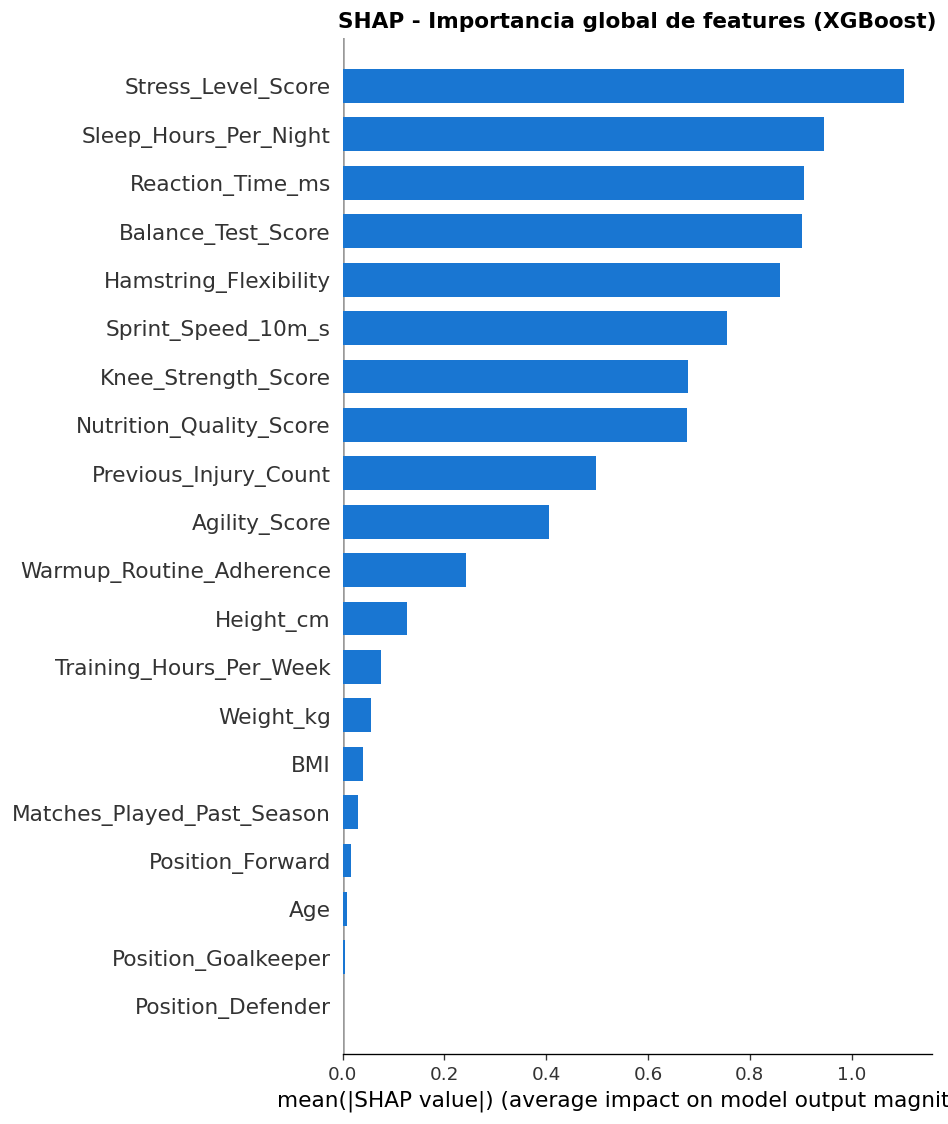

In [23]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_prep, feature_names=FEATURE_NAMES,
                  plot_type='bar', color='#1976D2', show=False)
plt.title('SHAP - Importancia global de features (XGBoost)',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('10_shap_bar.png', bbox_inches='tight')
plt.show()


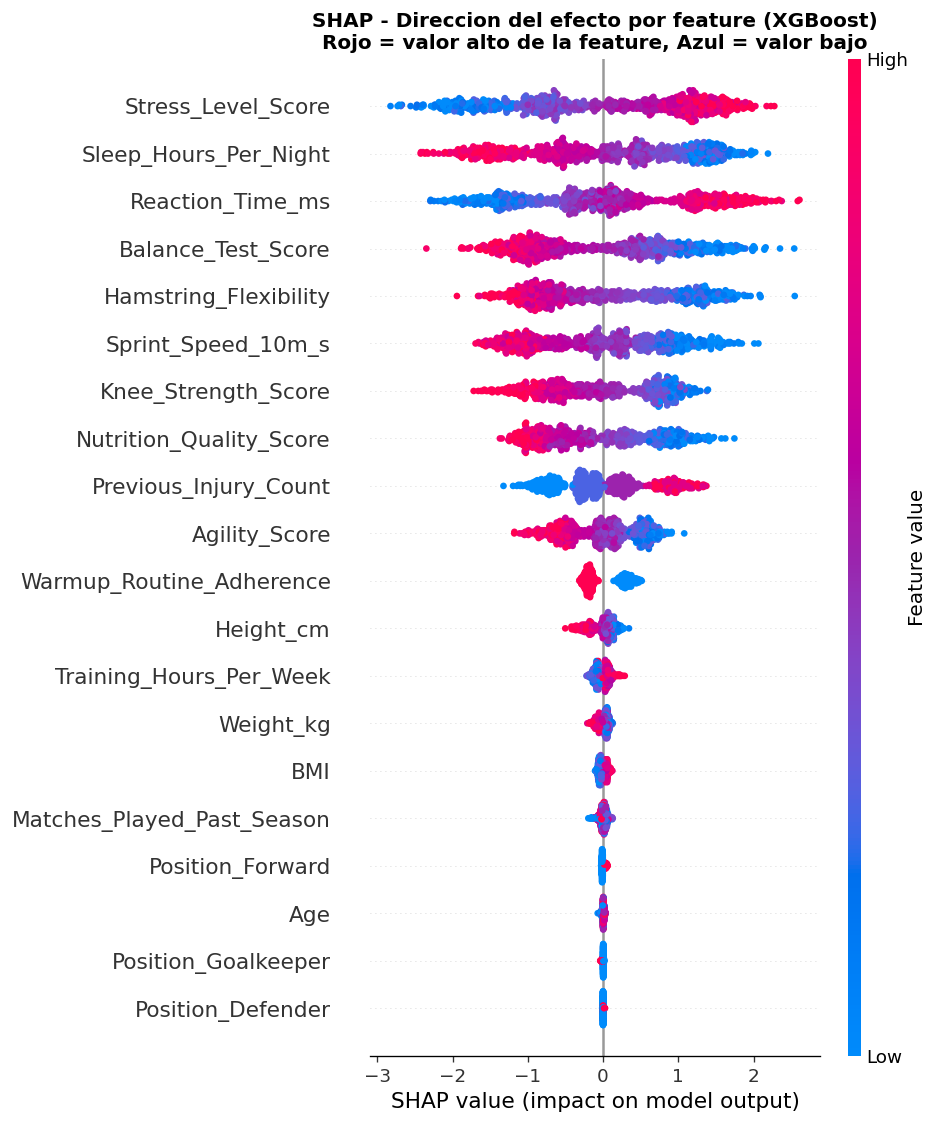

Interpretacion del beeswarm:
  Puntos a la derecha (SHAP > 0) -> empuja hacia predecir lesion
  Puntos a la izquierda (SHAP < 0) -> empuja hacia predecir no-lesion
  Color rojo = valor alto de la feature, azul = valor bajo


In [24]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_prep, feature_names=FEATURE_NAMES, show=False)
plt.title('SHAP - Direccion del efecto por feature (XGBoost)\n'
          'Rojo = valor alto de la feature, Azul = valor bajo',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('11_shap_beeswarm.png', bbox_inches='tight')
plt.show()

print('Interpretacion del beeswarm:')
print('  Puntos a la derecha (SHAP > 0) -> empuja hacia predecir lesion')
print('  Puntos a la izquierda (SHAP < 0) -> empuja hacia predecir no-lesion')
print('  Color rojo = valor alto de la feature, azul = valor bajo')


Jugador indice 0  |  Clase real: No lesion (0)


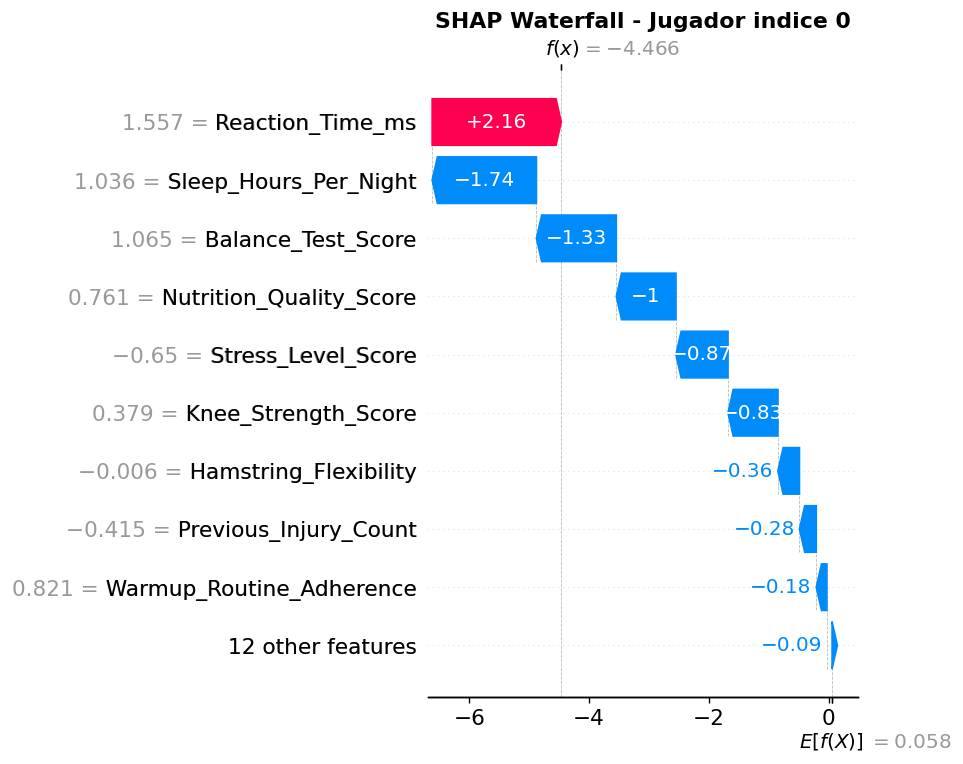

In [25]:
IDX = 0  # Cambia este indice para explorar otros jugadores

print(f'Jugador indice {IDX}  |  Clase real: '
      f'{"Lesion (1)" if y[IDX]==1 else "No lesion (0)"}')

shap_exp = shap.Explanation(
    values        = shap_values[IDX],
    base_values   = explainer.expected_value,
    data          = X_prep.iloc[IDX].values,
    feature_names = FEATURE_NAMES
)
plt.figure()
shap.plots.waterfall(shap_exp, show=False)
plt.title(f'SHAP Waterfall - Jugador indice {IDX}', fontweight='bold')
plt.tight_layout()
plt.savefig(f'12_shap_waterfall_jugador{IDX}.png', bbox_inches='tight')
plt.show()


---
## Resumen ejecutivo - Resultados para el informe


In [26]:
print('=' * 70)
print('RESUMEN EJECUTIVO - PIPELINE COMPLETO DE ML')
print('Prediccion de lesiones en futbolistas universitarios')
print('=' * 70)
print(f'Dataset: {df.shape[0]} jugadores | {N_FEATURES} features (tras OHE)')
print(f'Sin valores nulos | Balance 50/50 (artificial)')
print()
print('Configuracion:')
print('  Preprocesamiento : KNNImputer(k=5) -> StandardScaler -> SMOTE (dentro del fold)')
print('  Validacion       : 5-Fold Stratified CV | umbral tau por criterio de Youden')
print('  Metricas         : AUC-ROC (principal) | F1-Score (secundaria)')
print()
print('RESULTADOS COMPARATIVOS:')
print(f'{"Modelo":35s}  {"AUC-ROC":>17}  {"F1-Score":>17}  {">=0.75":>6}')
print('-' * 82)
for name, m in results.items():
    ok = 'SI' if m['AUC_mean'] >= 0.75 else 'NO'
    print(f'{name:35s}  '
          f'{m["AUC_mean"]:.4f}+/-{m["AUC_std"]:.4f}  '
          f'{m["F1_mean"]:.4f}+/-{m["F1_std"]:.4f}  '
          f'{ok:>6}')
print()
print('TOP FEATURES (RF + SHAP):')
print('  1. Stress_Level_Score      - factor de riesgo mas fuerte')
print('  2. Sleep_Hours_Per_Night   - factor protector mas fuerte')
print('  3. Reaction_Time_ms        - estado neuromuscular')
print('  4. Balance_Test_Score      - equilibrio y propiocepcion')
print('  5. Hamstring_Flexibility   - flexibilidad de isquiotibiales')
print()
print('LIMITACION PRINCIPAL:')
print('  AUC ~0.99 refleja la naturaleza sintetica/balanceada del dataset.')
print('  En datos reales (Rossi et al., 2018) el problema es mas dificil (AUC ~0.76).')
print('  Mencionar explicitamente en conclusiones del informe.')


RESUMEN EJECUTIVO - PIPELINE COMPLETO DE ML
Prediccion de lesiones en futbolistas universitarios
Dataset: 800 jugadores | 21 features (tras OHE)
Sin valores nulos | Balance 50/50 (artificial)

Configuracion:
  Preprocesamiento : KNNImputer(k=5) -> StandardScaler -> SMOTE (dentro del fold)
  Validacion       : 5-Fold Stratified CV | umbral tau por criterio de Youden
  Metricas         : AUC-ROC (principal) | F1-Score (secundaria)

RESULTADOS COMPARATIVOS:
Modelo                                         AUC-ROC           F1-Score  >=0.75
----------------------------------------------------------------------------------
Regresion Logistica (baseline)       0.9902+/-0.0027  0.9581+/-0.0034      SI
Random Forest                        0.9858+/-0.0040  0.9467+/-0.0067      SI
XGBoost                              0.9865+/-0.0049  0.9482+/-0.0142      SI

TOP FEATURES (RF + SHAP):
  1. Stress_Level_Score      - factor de riesgo mas fuerte
  2. Sleep_Hours_Per_Night   - factor protector mas fuer

## Prediccion de lesion para un jugador nuevo

Modifica los valores en la seccion **DATOS DEL JUGADOR** y ejecuta la celda.  
El bloque calcula el BMI automaticamente a partir de peso y altura.  

**Prerequisito:** haber ejecutado todo el notebook principal primero (necesita , , ,  ya definidos).

### Rangos de referencia

| Variable | Min | Media | Max | Nota |
|---|---|---|---|---|
| Age | 18 | 21 | 24 | años |
| Height_cm | 154 | 177 | 200 | cm |
| Weight_kg | 45 | 73 | 105 | kg |
| Training_Hours_Per_Week | 5 | 10 | 19 | horas/semana |
| Matches_Played_Past_Season | 5 | 22 | 39 | partidos |
| Previous_Injury_Count | 0 | 1.5 | 8 | lesiones previas |
| Knee_Strength_Score | 52 | 75 | 94 | alto = mejor |
| Hamstring_Flexibility | 58 | 79 | 100 | alto = mejor |
| Reaction_Time_ms | 180 | 249 | 307 | **bajo = mejor** |
| Balance_Test_Score | 60 | 84 | 100 | alto = mejor |
| Sprint_Speed_10m_s | 4.9 | 5.9 | 6.9 | **bajo = mejor** |
| Agility_Score | 50 | 78 | 100 | alto = mejor |
| Sleep_Hours_Per_Night | 5 | 7.4 | 10 | alto = mejor |
| Stress_Level_Score | 22 | 54 | 87 | **alto = PEOR** |
| Nutrition_Quality_Score | 50 | 74 | 100 | alto = mejor |
| Warmup_Routine_Adherence | 0 | - | 1 | 0=No / 1=Si |


  RESULTADO DE PREDICCION

  Regresion Logistica (baseline)
  Probabilidad de lesion : 100.0%
  [#############################.]
  -> ALTO RIESGO de lesion

  Random Forest
  Probabilidad de lesion : 100.0%
  [##############################]
  -> ALTO RIESGO de lesion

  XGBoost
  Probabilidad de lesion : 100.0%
  [#############################.]
  -> ALTO RIESGO de lesion

  Probabilidad promedio (3 modelos) : 100.0%

  VEREDICTO: ALTO RIESGO — Se recomienda revision medica preventiva


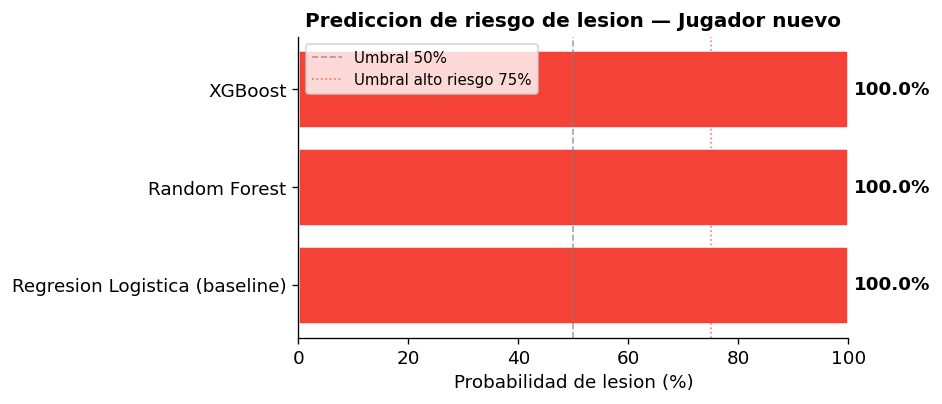


EXPLICACION: factores que mas influyeron en esta prediccion
(usando XGBoost — el mas interpretable con SHAP)


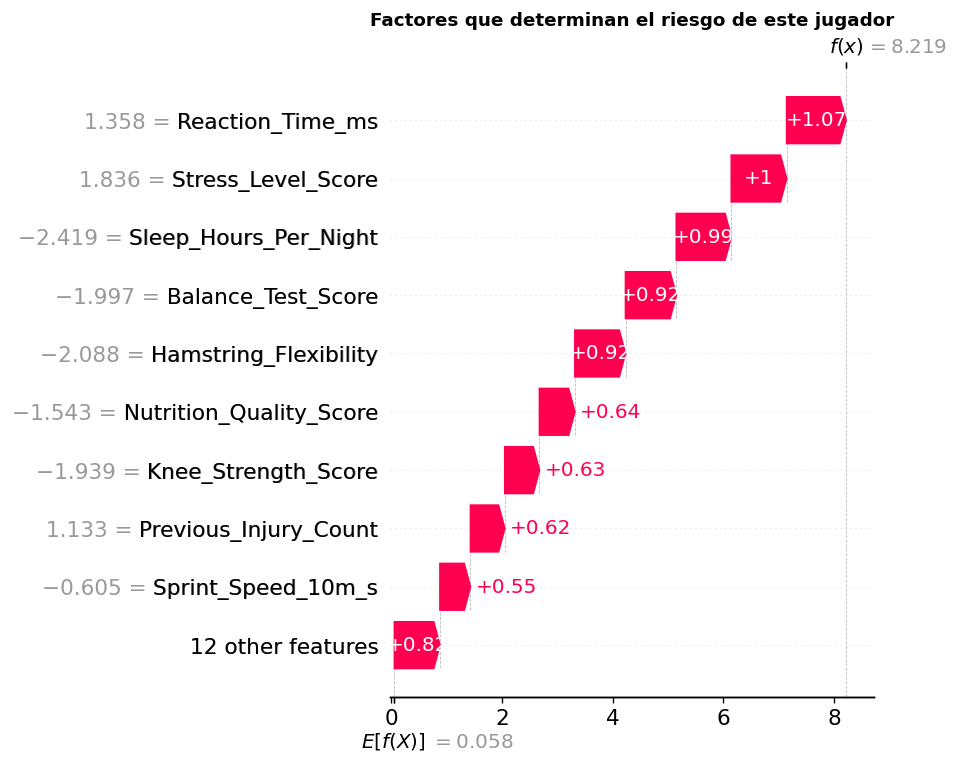


Interpretacion del grafico SHAP:
  Barras ROJAS   -> factores que AUMENTAN el riesgo de lesion
  Barras AZULES  -> factores que REDUCEN el riesgo de lesion
  El valor de salida (f(x)) es la probabilidad logit del modelo


In [27]:
# ══════════════════════════════════════════════════════════════
# PREDICCION DE LESION PARA UN JUGADOR NUEVO
# Podemos modificar los valores de la seccion "DATOS DEL JUGADOR"
# para observar distintos resultados
# ══════════════════════════════════════════════════════════════

# ── DATOS DEL JUGADOR — MODIFICAR AQUI ─────────────────────────
jugador = {
    # Datos basicos
    'Age':                        21,      # edad en años          [18 - 24]
    'Height_cm':                 177,      # altura en cm          [154 - 200]
    'Weight_kg':                  73,      # peso en kg            [45 - 105]
    'Position':             'Forward',     # Midfielder / Forward / Defender / Goalkeeper

    # Carga de entrenamiento
    'Training_Hours_Per_Week':    14,      # horas/semana          [5 - 19]
    'Matches_Played_Past_Season': 30,      # partidos jugados      [5 - 39]

    # Historial medico
    'Previous_Injury_Count':       3,      # lesiones previas      [0 - 8]

    # Condicion fisica
    'Knee_Strength_Score':        62,      # fuerza rodilla        [52 - 94]  (alto = mejor)
    'Hamstring_Flexibility':      65,      # flexib. isquio (cm)   [58 - 100] (alto = mejor)
    'Reaction_Time_ms':          280,      # tiempo reaccion (ms)  [180 - 307](bajo = mejor)
    'Balance_Test_Score':         70,      # equilibrio            [60 - 100] (alto = mejor)
    'Sprint_Speed_10m_s':        5.75,     # velocidad 10m (s)     [4.9 - 6.9](bajo = mejor)
    'Agility_Score':              65,      # agilidad              [50 - 100] (alto = mejor)

    # Estilo de vida
    'Sleep_Hours_Per_Night':     5.5,      # horas de sueno/noche  [5 - 10]   (alto = mejor)
    'Stress_Level_Score':         75,      # nivel de estres       [22 - 87]  (alto = PEOR)
    'Nutrition_Quality_Score':    60,      # calidad nutricional   [50 - 100] (alto = mejor)
    'Warmup_Routine_Adherence':    0,      # hace calentamiento?   0 = No / 1 = Si
}
# ── FIN DE DATOS — NO MODIFICAR LO DE ABAJO ───────────────────


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

# Calcular BMI automaticamente
jugador['BMI'] = jugador['Weight_kg'] / (jugador['Height_cm'] / 100) ** 2

# Convertir a DataFrame y aplicar OHE igual que en entrenamiento
jugador_df = pd.DataFrame([jugador])
jugador_ohe = pd.get_dummies(jugador_df, columns=['Position'], drop_first=False)

# Asegurar que tenga exactamente las mismas columnas que X (en el mismo orden)
for col in FEATURE_NAMES:
    if col not in jugador_ohe.columns:
        jugador_ohe[col] = 0
jugador_ohe = jugador_ohe[FEATURE_NAMES]

# ── Prediccion con el mejor modelo (LR baseline) ──────────────
# Usamos los 3 modelos y mostramos consenso
probabilidades = {}
for name, pipeline in MODELS_FULL.items():
    prob = pipeline.predict_proba(jugador_ohe)[0, 1]
    probabilidades[name] = prob

prob_promedio = np.mean(list(probabilidades.values()))

# ── Resultado visual ───────────────────────────────────────────
print("=" * 55)
print("  RESULTADO DE PREDICCION")
print("=" * 55)

for name, prob in probabilidades.items():
    barra = int(prob * 30)
    print(f"\n  {name}")
    print(f"  Probabilidad de lesion : {prob*100:.1f}%")
    print(f"  [{'#' * barra}{'.' * (30 - barra)}]")
    if prob >= 0.75:
        print(f"  -> ALTO RIESGO de lesion")
    elif prob >= 0.50:
        print(f"  -> RIESGO MODERADO de lesion")
    else:
        print(f"  -> BAJO RIESGO de lesion")

print()
print(f"  Probabilidad promedio (3 modelos) : {prob_promedio*100:.1f}%")
print()

if prob_promedio >= 0.75:
    veredicto = "ALTO RIESGO — Se recomienda revision medica preventiva"
    color_v = '#F44336'
elif prob_promedio >= 0.50:
    veredicto = "RIESGO MODERADO — Monitorear carga y estres"
    color_v = '#FF9800'
else:
    veredicto = "BAJO RIESGO — Continuar con el programa habitual"
    color_v = '#4CAF50'

print(f"  VEREDICTO: {veredicto}")
print("=" * 55)

# ── Grafico de probabilidades ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3.5))
nombres  = list(probabilidades.keys())
probs    = [p * 100 for p in probabilidades.values()]
colores  = ['#F44336' if p >= 75 else '#FF9800' if p >= 50 else '#4CAF50' for p in probs]

bars = ax.barh(nombres, probs, color=colores, edgecolor='white', linewidth=1.5)
ax.axvline(50,  color='gray',   linestyle='--', linewidth=1, alpha=0.7, label='Umbral 50%')
ax.axvline(75,  color='#F44336', linestyle=':',  linewidth=1, alpha=0.7, label='Umbral alto riesgo 75%')
ax.set_xlim(0, 100)
ax.set_xlabel('Probabilidad de lesion (%)')
ax.set_title('Prediccion de riesgo de lesion — Jugador nuevo',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
for bar, val in zip(bars, probs):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('13_prediccion_jugador_nuevo.png', bbox_inches='tight')
plt.show()

# ── SHAP Waterfall — por que el modelo tomo esa decision ───────
print()
print("EXPLICACION: factores que mas influyeron en esta prediccion")
print("(usando XGBoost — el mas interpretable con SHAP)")

prep_only = __import__('sklearn.pipeline', fromlist=['Pipeline']).Pipeline([
    ('imputer', __import__('sklearn.impute', fromlist=['KNNImputer']).KNNImputer(n_neighbors=5)),
    ('scaler',  __import__('sklearn.preprocessing', fromlist=['StandardScaler']).StandardScaler()),
])
prep_only.fit(X, y)
jugador_prep = pd.DataFrame(prep_only.transform(jugador_ohe), columns=FEATURE_NAMES)

shap_jug = explainer.shap_values(jugador_prep)

shap_exp = shap.Explanation(
    values        = shap_jug[0],
    base_values   = explainer.expected_value,
    data          = jugador_prep.iloc[0].values,
    feature_names = FEATURE_NAMES
)
plt.figure()
shap.plots.waterfall(shap_exp, show=False)
plt.title('Factores que determinan el riesgo de este jugador',
          fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('14_shap_jugador_nuevo.png', bbox_inches='tight')
plt.show()

print()
print("Interpretacion del grafico SHAP:")
print("  Barras ROJAS   -> factores que AUMENTAN el riesgo de lesion")
print("  Barras AZULES  -> factores que REDUCEN el riesgo de lesion")
print("  El valor de salida (f(x)) es la probabilidad logit del modelo")
